In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import numpy as np
import os


In [2]:

def prepare_dataset(filename, config):
    print(f"\n--- Processing: {filename} ---")
    
    # 1. Configuration & Pathing
    # Look in results folder first, fallback to current dir or parent dir
    possible_paths =[
        f'../GradientInformation/results/{filename}',
        f'../GradientInformation/{filename}',
        filename
    ]
    
    file_path = next((p for p in possible_paths if os.path.exists(p)), None)
    if not file_path:
        raise FileNotFoundError(f"Cannot find '{filename}' in expected directories.")

    df = pd.read_csv(file_path)
    print(f"✅ Loaded {len(df)} experiment records.")

    # 2. Data Parsing & Flattening
    expanded_rows = []
    summary_rows =[]

    # Dynamic label for the policy method based on config
    policy_label = f"{config['method']} Policy"
    if config['peft'] == "on":
         policy_label += " (PEFT)"

    method_map = {
        'policy': policy_label,
        'grad_norm_preserved_random_dir': 'Grad Norm Noisy',
        'random': 'Random Noise'
    }

    print("Parsing trajectories...")
    for idx, row in df.iterrows():
        method_name = method_map.get(row['method'], row['method'])
        mh_label = "With MH" if row.get('mh_enabled', False) else "No MH"

        # Safely parse the trajectory string
        try:
            traj_data = row.get('trajectory', '[]')
            traj_list = ast.literal_eval(traj_data) if isinstance(traj_data, str) else traj_data
        except Exception as e:
            print(f"Skipping sample {idx} due to parsing error: {e}")
            continue

        # A. Flatten trajectory for line plots
        for step_data in traj_list:
            expanded_rows.append({
                "Sample": row['sample_idx'],
                "Method": method_name,
                "Sampling": mh_label,
                "Step": step_data.get('step', 0),
                # Fallbacks handle difference between Multi-token (avg_l2_distance) and Single-token (l2_distance)
                "L2 Distance": step_data.get('avg_l2_distance', step_data.get('l2_distance', np.nan)),
                "KL Divergence": step_data.get('avg_kl_divergence', step_data.get('kl_divergence', np.nan)),
                "Entropy": step_data.get('entropy', np.nan)
            })

        # B. Append to summary data for bar charts
        # Handle Accuracy vs Success
        acc = row.get('accuracy_pct', np.nan)
        if pd.isna(acc) and 'success' in row:
            acc = 100.0 if row['success'] else 0.0

        summary_rows.append({
            "Sample": row['sample_idx'],
            "Method": method_name,
            "Sampling": mh_label,
            # Fallbacks handle difference between Multi-token (avg_l2_dist) and Single-token (l2_dist)
            "Final L2": row.get('avg_l2_dist', row.get('l2_dist', np.nan)),
            "Final KL": row.get('avg_kl_div', row.get('kl_div', np.nan)),
            "Accuracy %": acc
        })

    traj_df = pd.DataFrame(expanded_rows)
    summary_df = pd.DataFrame(summary_rows)

    if traj_df.empty:
        raise ValueError("Parsed trajectory dataframe is empty. Check your CSV contents.")

    print(f"✅ Successfully prepared step & summary records.")
    return traj_df, summary_df



In [3]:

def plot_graphs(traj_df, summary_df, config):
    # Set visual style
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    palette = sns.color_palette("deep", len(traj_df['Method'].unique()))
    
    # Create dynamic config subtitle for plots
    config_str = f"{config['method']} | {config['tokens_masked'].title()} Token | PEFT: {config['peft']} | GN: {config['gradient_normalization']} | Oracle: {config['oracle']}"

    # =============================================================================
    # FIGURE 1: Trajectory Dynamics (Step-by-step)
    # =============================================================================
    fig1, axes1 = plt.subplots(1, 3, figsize=(22, 6))
    fig1.suptitle(f'Optimization Trajectories\n{config_str}', fontsize=16, y=1.08)

    # A. L2 Distance
    sns.lineplot(data=traj_df, x="Step", y="L2 Distance", hue="Method", style="Sampling", palette=palette, ax=axes1[0], linewidth=2.5, errorbar=None)
    axes1[0].set_title("Embedding Distance (L2)")
    axes1[0].set_ylabel("L2 Distance (Lower is better)")

    # B. KL Divergence
    sns.lineplot(data=traj_df, x="Step", y="KL Divergence", hue="Method", style="Sampling", palette=palette, ax=axes1[1], linewidth=2.5, errorbar=None)
    axes1[1].set_title("Contextual Fit (KL Divergence)")
    axes1[1].set_ylabel("KL Div (Lower is better)")

    # C. Entropy (Handles empty gracefully if Single Token lacks it)
    if not traj_df['Entropy'].isna().all():
        sns.lineplot(data=traj_df, x="Step", y="Entropy", hue="Method", style="Sampling", palette=palette, ax=axes1[2], linewidth=2.5, errorbar=None)
        axes1[2].set_title("Prediction Uncertainty (Entropy)")
        axes1[2].set_ylabel("Entropy")
    else:
        axes1[2].text(0.5, 0.5, 'Entropy data not tracked\nin Single-token runs', ha='center', va='center', color='gray')
        axes1[2].set_title("Prediction Uncertainty (Entropy)")

    axes1[0].get_legend().remove()
    axes1[1].get_legend().remove()
    axes1[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

    # =============================================================================
    # FIGURE 2: Final Summary (Bar Charts)
    # =============================================================================
    fig2, axes2 = plt.subplots(1, 3, figsize=(22, 6))
    fig2.suptitle(f'Final Aggregated Performance\n{config_str}', fontsize=16, y=1.08)

    # A. Final L2 Distance
    sns.barplot(data=summary_df, x="Method", y="Final L2", hue="Sampling", ax=axes2[0], palette="Blues_d", capsize=0.1, err_kws={'linewidth': 1.5})
    axes2[0].set_title("Final L2 Distance")
    axes2[0].set_ylabel("L2 Distance")

    # B. Final KL Divergence
    sns.barplot(data=summary_df, x="Method", y="Final KL", hue="Sampling", ax=axes2[1], palette="Oranges_d", capsize=0.1, err_kws={'linewidth': 1.5})
    axes2[1].set_title("Final KL Divergence")
    axes2[1].set_ylabel("KL Divergence")

    # C. Accuracy
    sns.barplot(data=summary_df, x="Method", y="Accuracy %", hue="Sampling", ax=axes2[2], palette="Greens_d", capsize=0.1, err_kws={'linewidth': 1.5})
    axes2[2].set_title("Exact Token Recovery Rate")
    axes2[2].set_ylabel("Accuracy %")
    axes2[2].set_ylim(0, 100)

    plt.tight_layout()
    plt.show()



--- Processing: experiment_results_cls_multi_steps_50_gn_False_oracle_False_samples_250_date_2026-04-13.csv ---
✅ Loaded 1500 experiment records.
Parsing trajectories...
✅ Successfully prepared step & summary records.


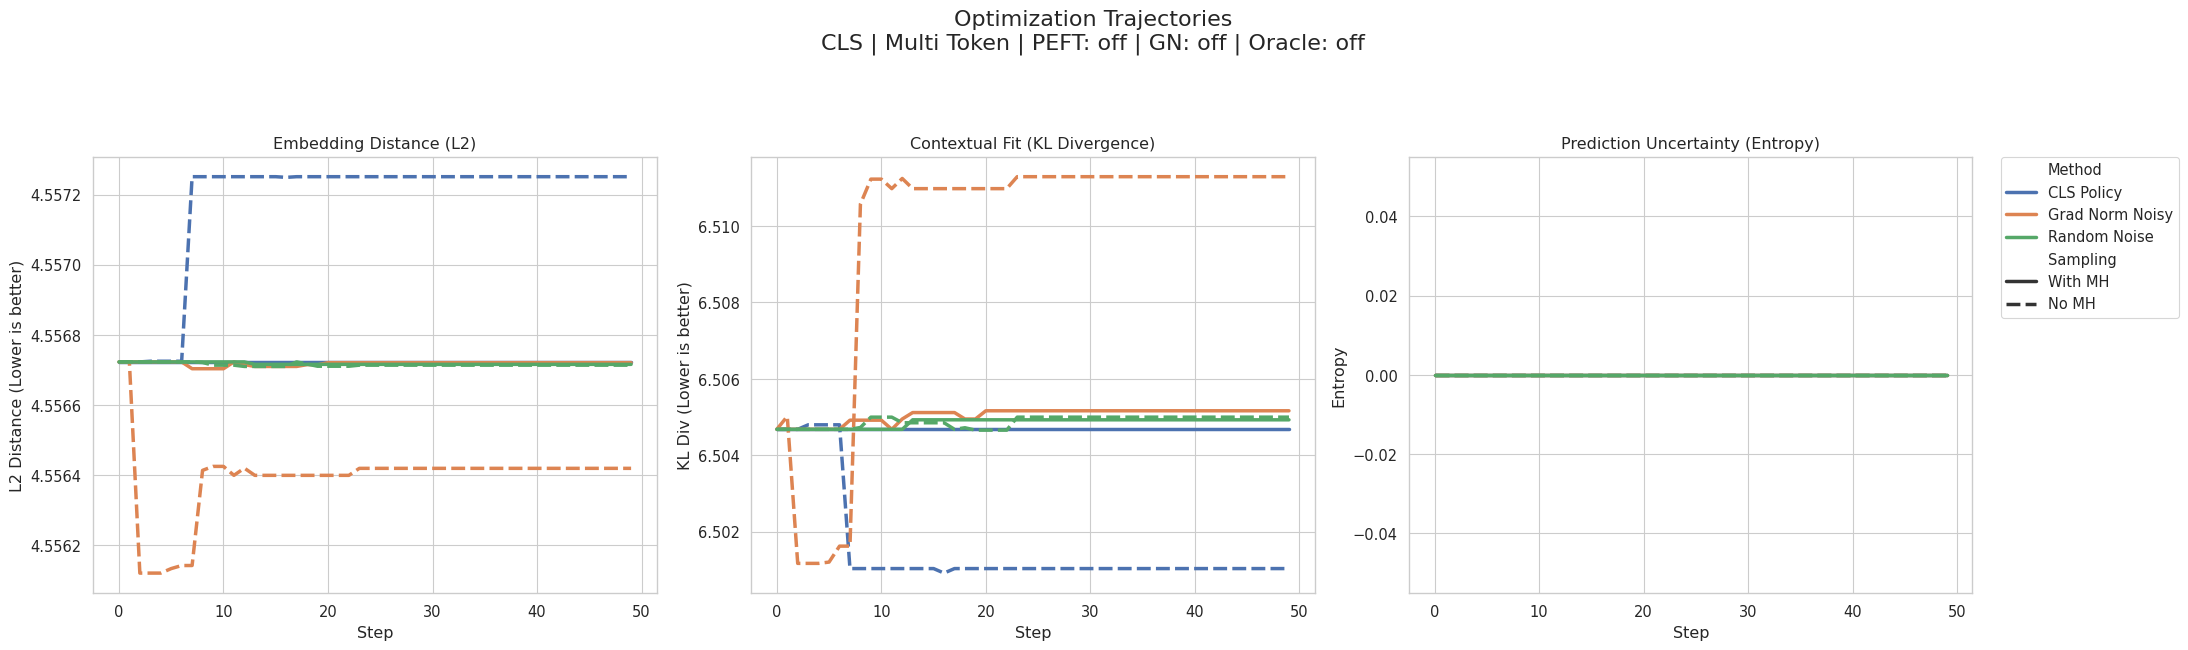

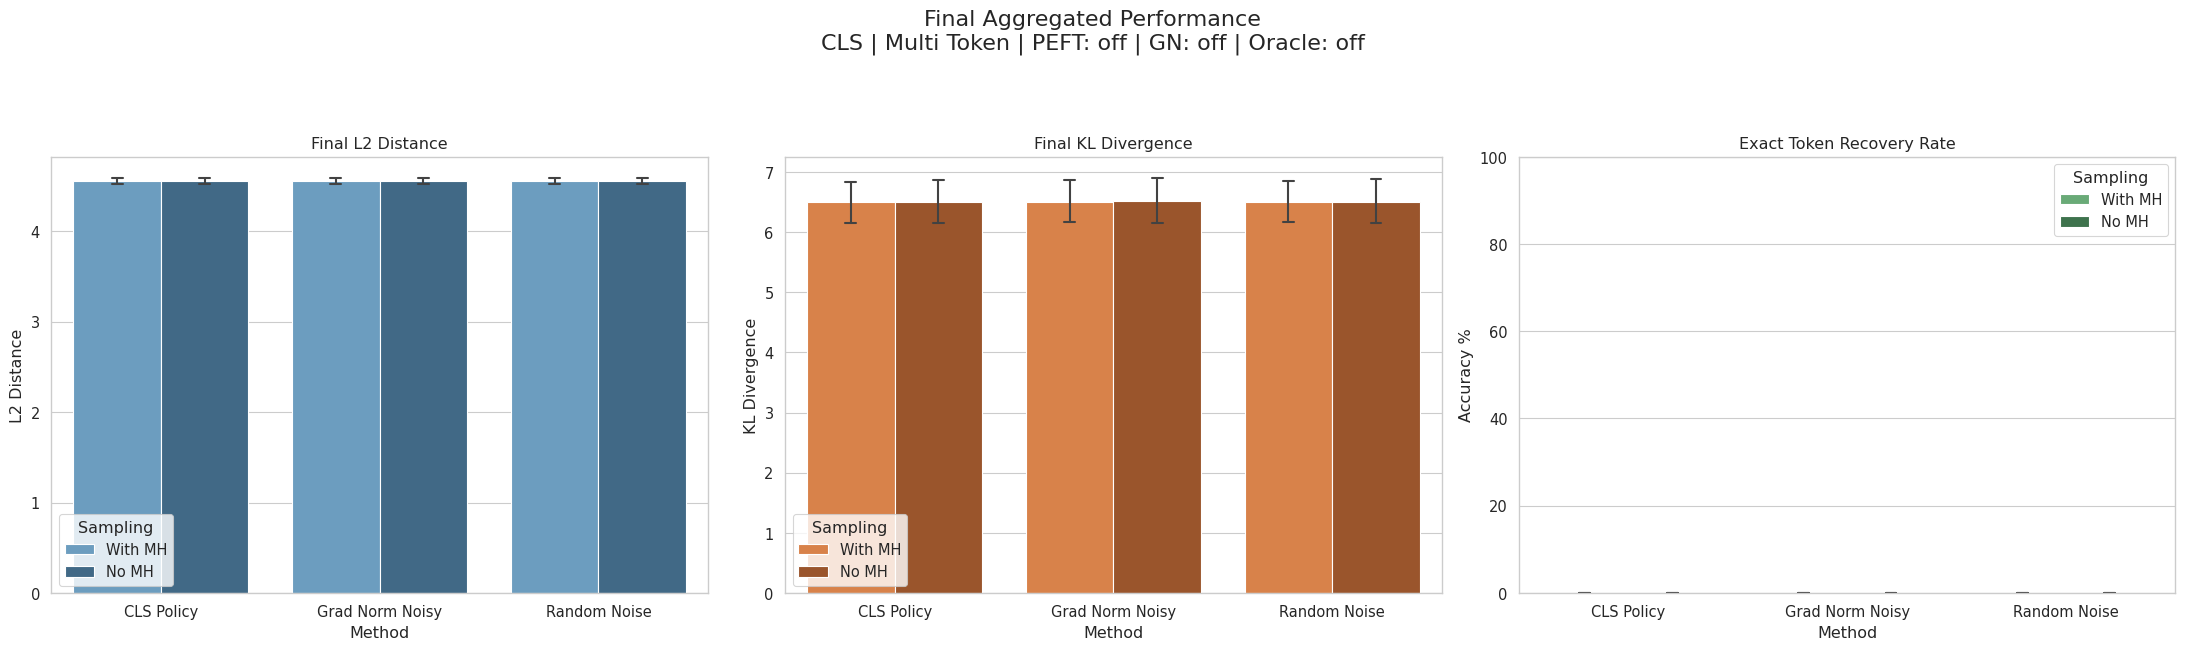


--- Processing: experiment_results_dls_multi_sentences_steps_50_gn_True_oracle_False_samples_250_date_2026-04-13.csv ---
✅ Loaded 1500 experiment records.
Parsing trajectories...
✅ Successfully prepared step & summary records.


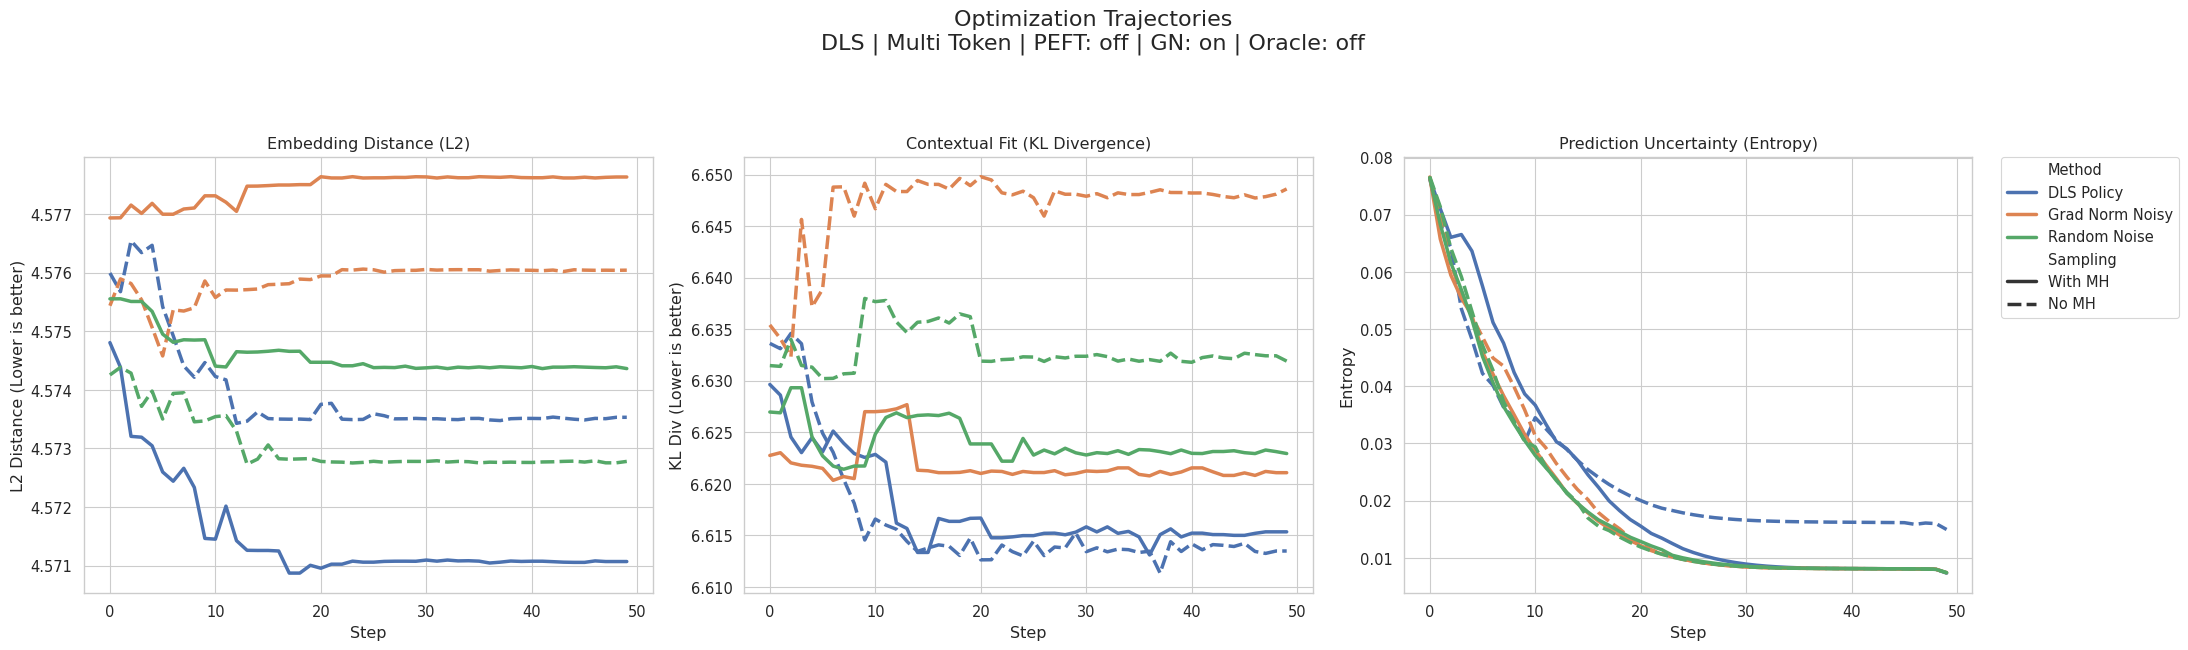

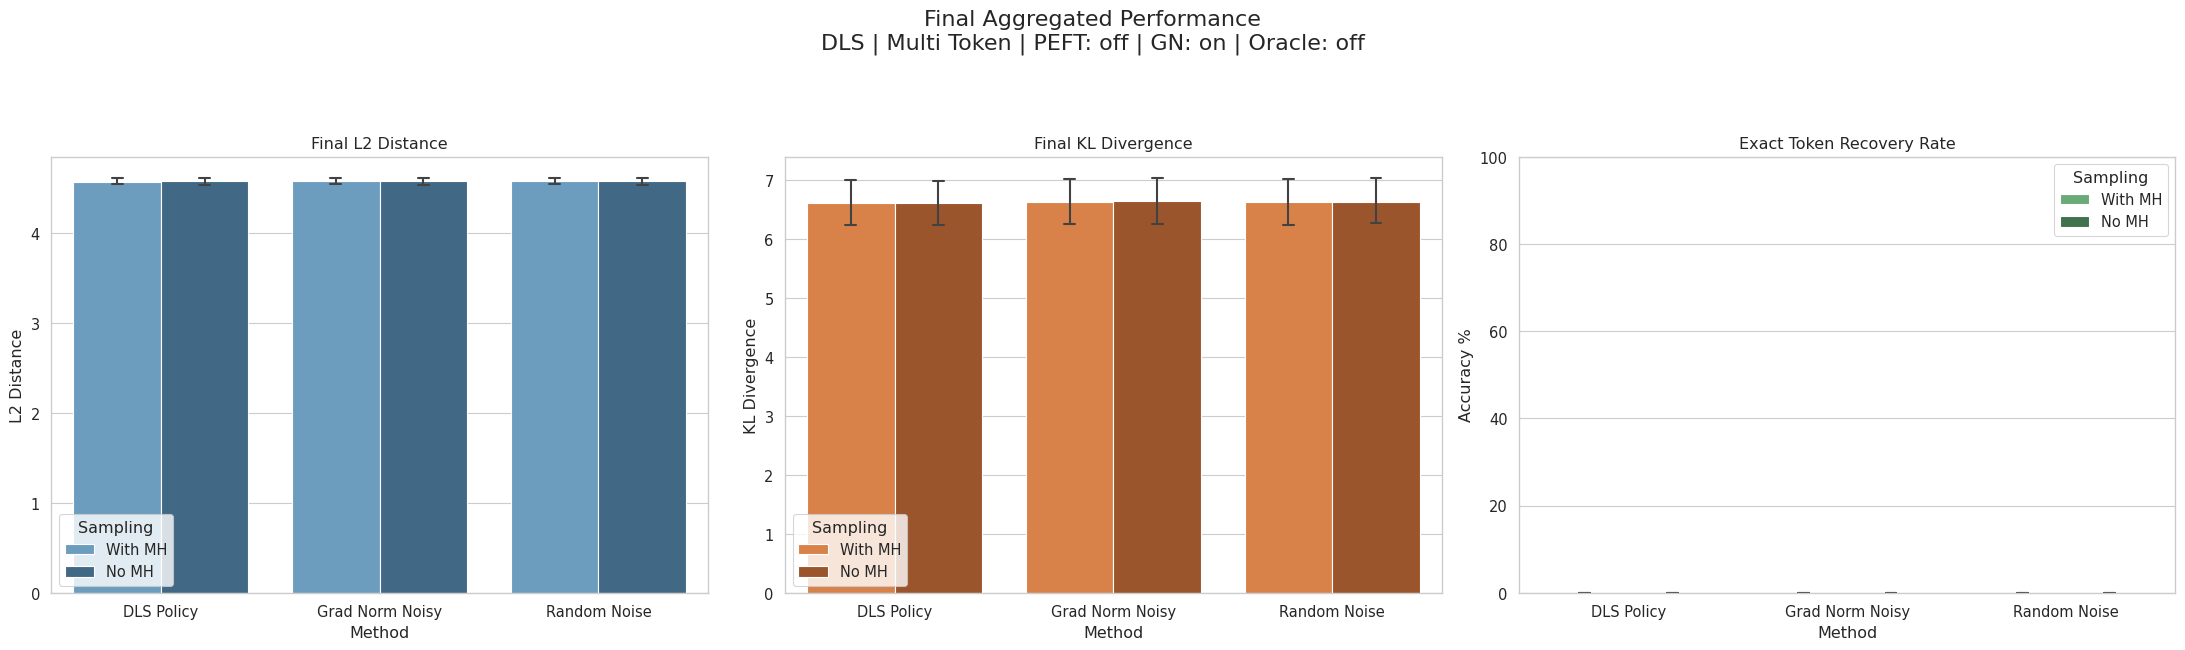


--- Processing: experiment_results_cls_multi_steps_50_gn_False_oracle_False_samples_250_date_2026-04-16_peft_True_model_name_gpt2_sft.csv ---
✅ Loaded 1500 experiment records.
Parsing trajectories...
✅ Successfully prepared step & summary records.


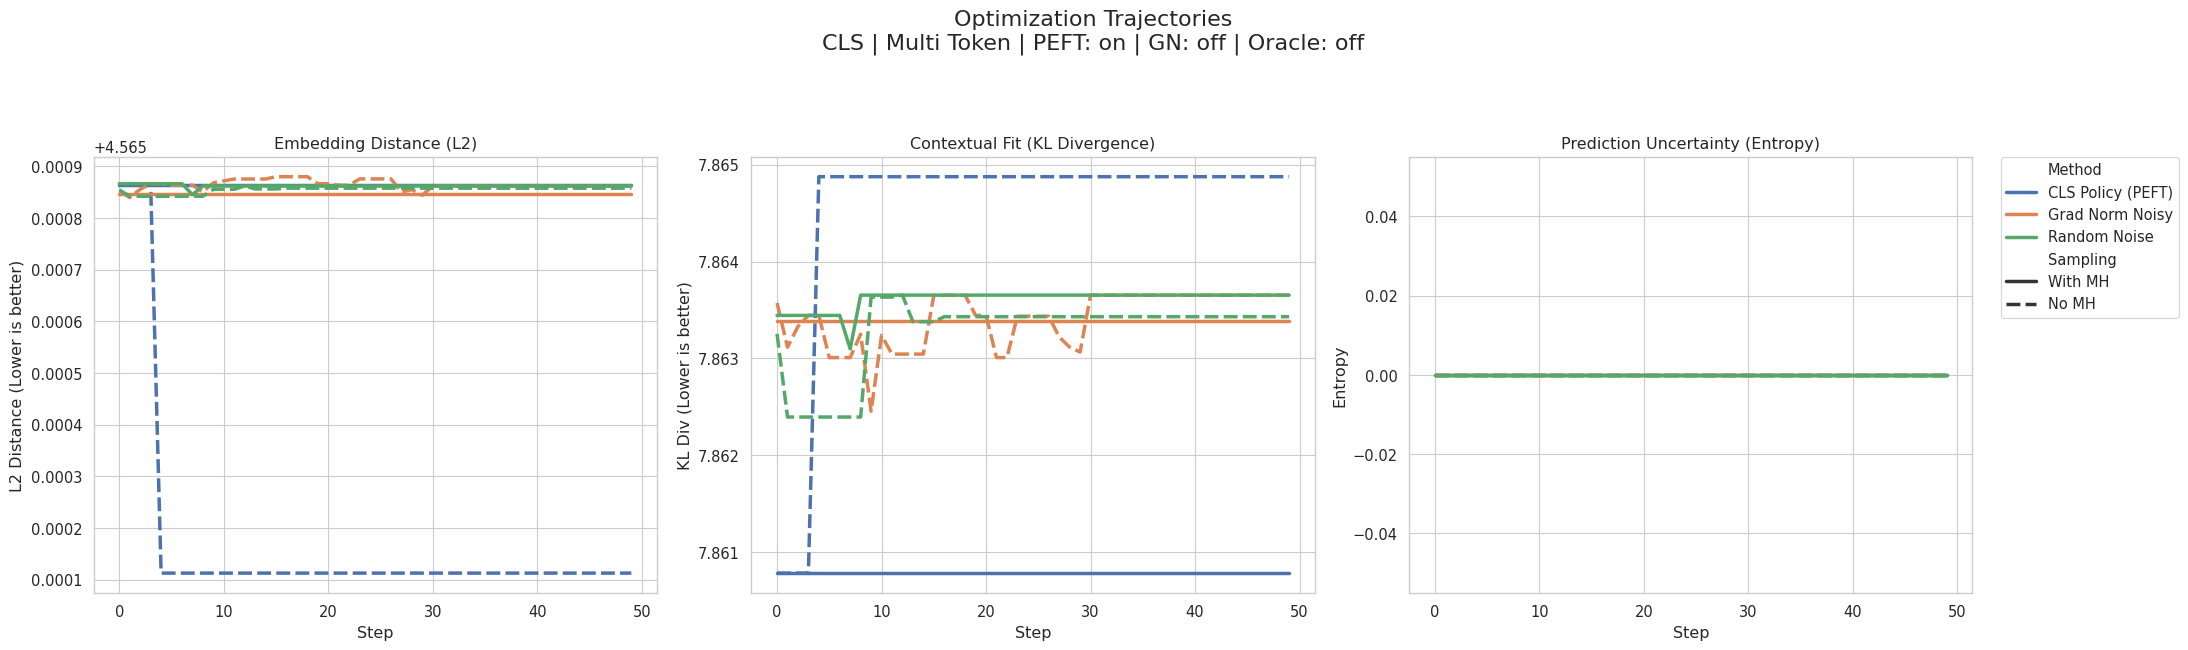

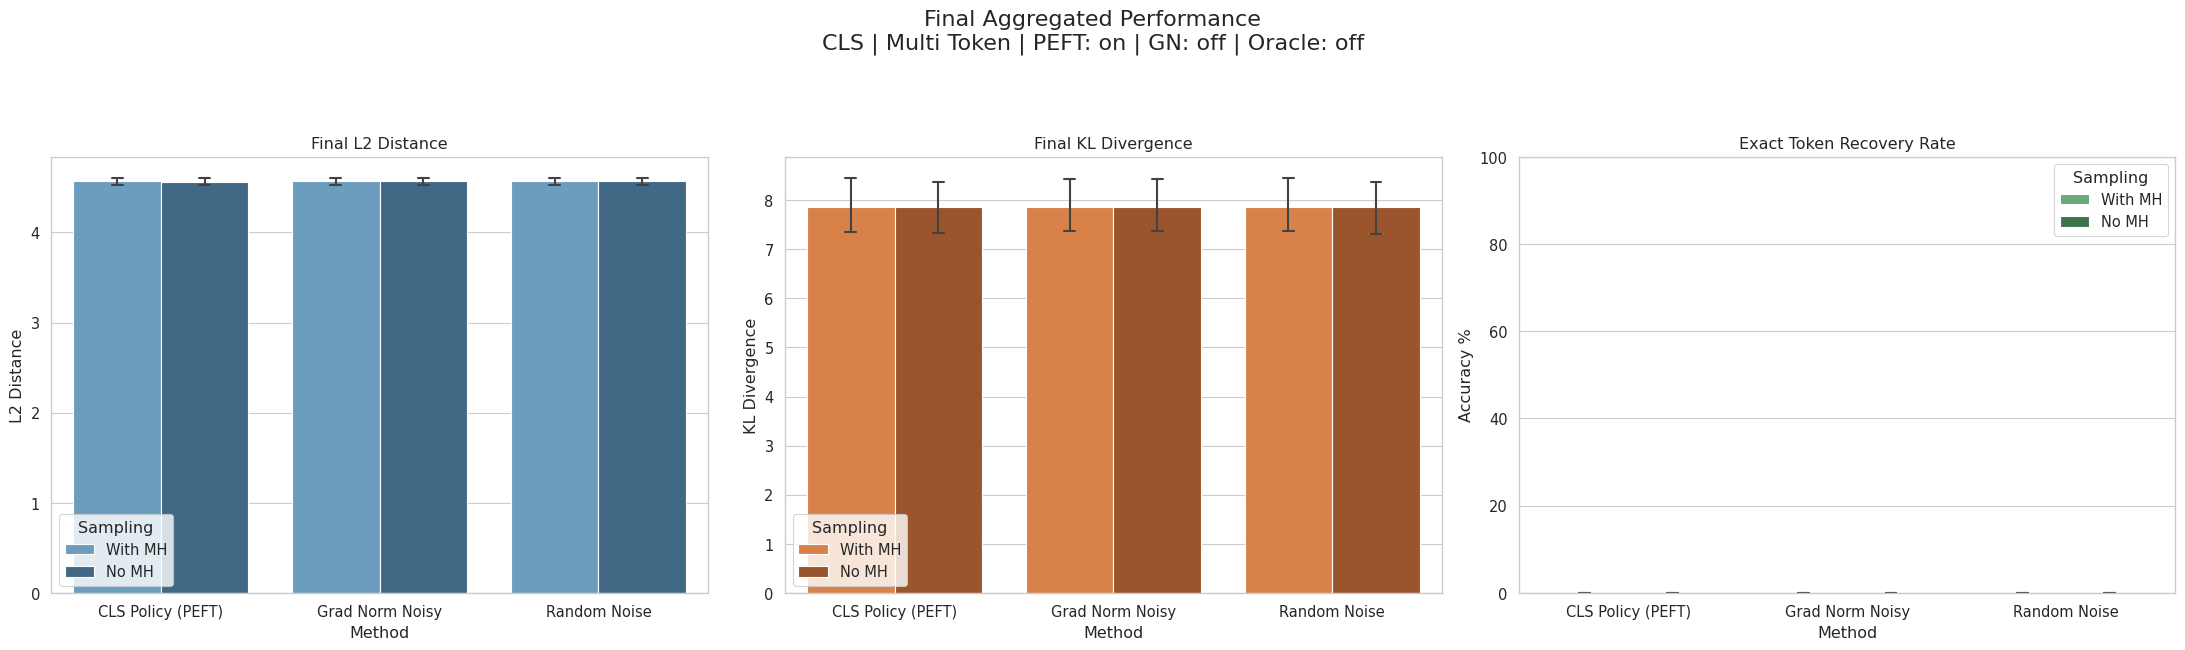


--- Processing: experiment_results_dls_multi_sentences_steps_50_gn_True_oracle_False_samples_250_date_2026-04-16_peft_True_model_name_gpt2_sft.csv ---
✅ Loaded 1500 experiment records.
Parsing trajectories...
✅ Successfully prepared step & summary records.


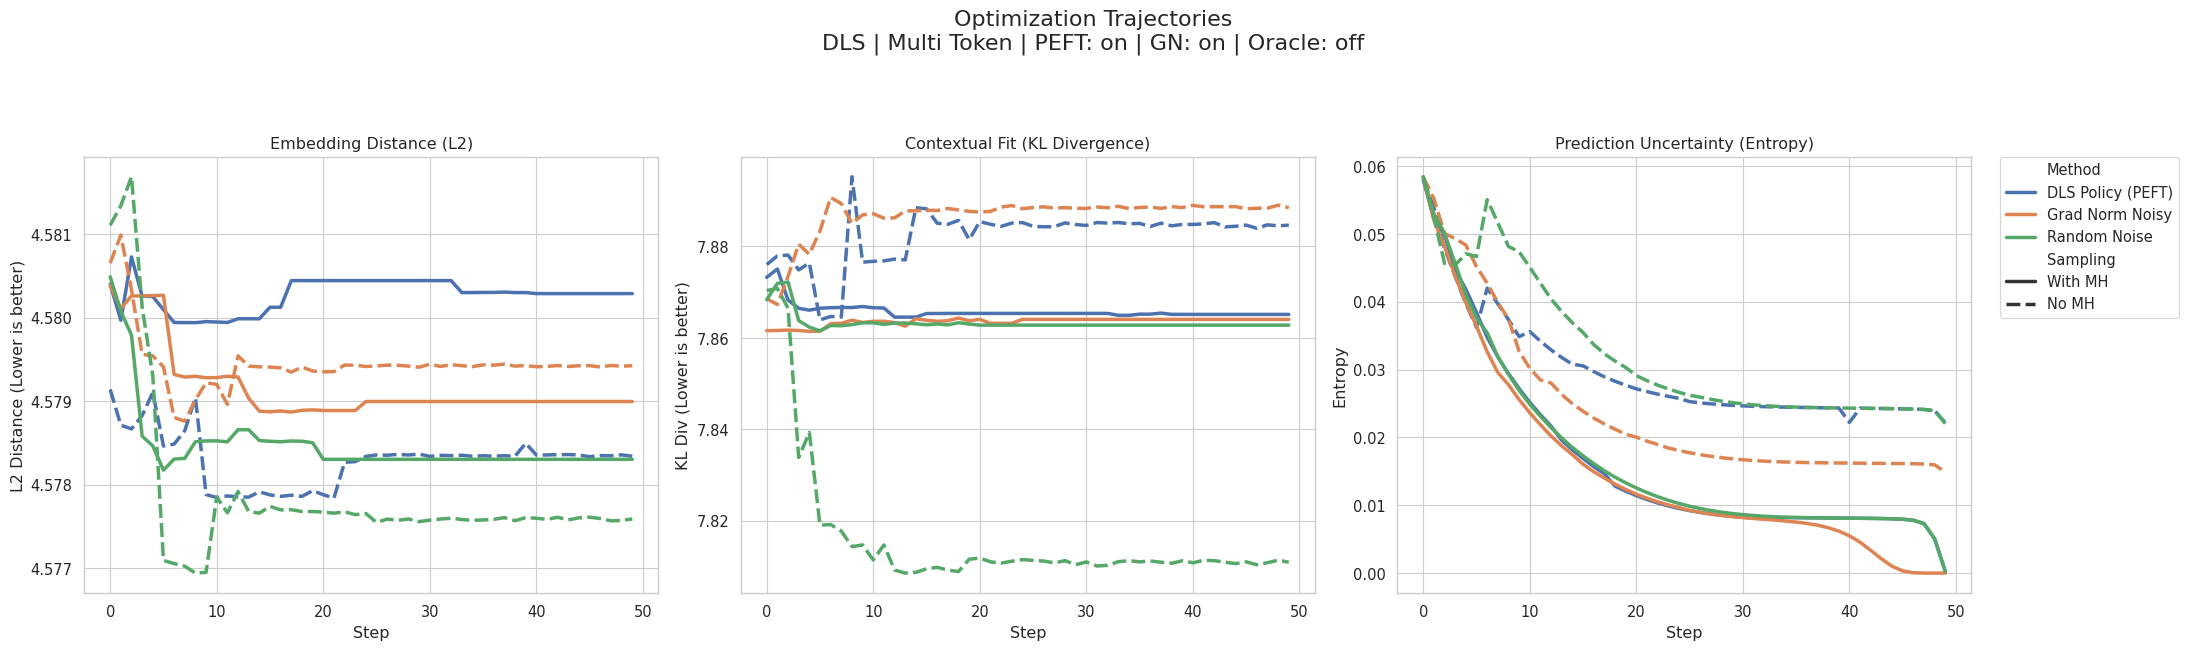

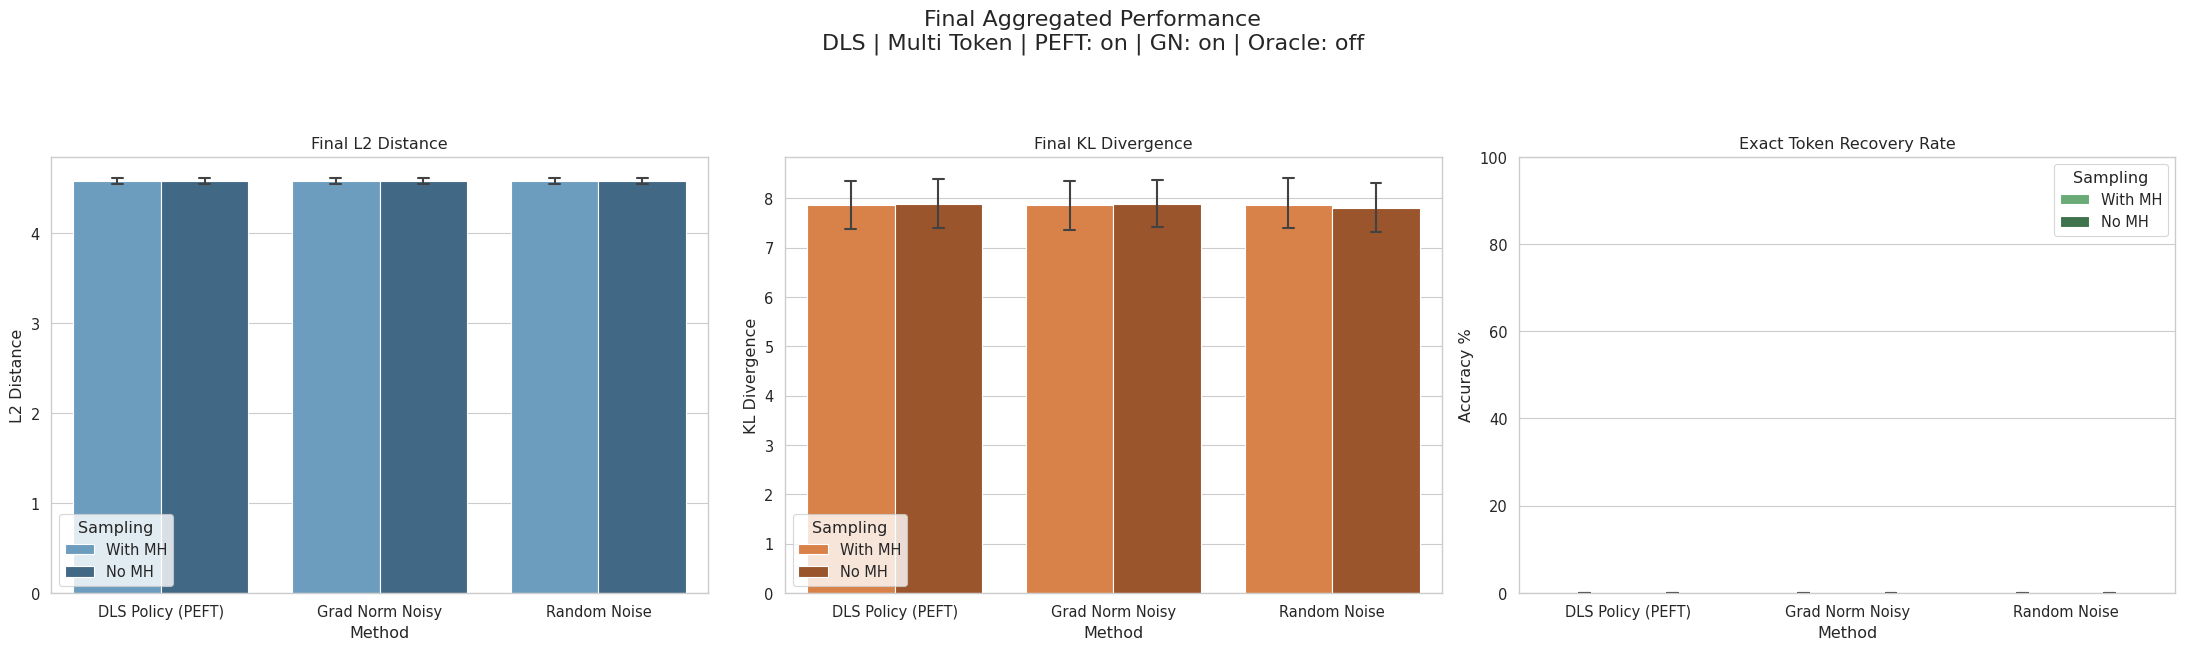


--- Processing: experiment_results_cls_single_steps_50_gn_False_oracle_False_samples_250_date_2026-04-13.csv ---
✅ Loaded 1500 experiment records.
Parsing trajectories...
✅ Successfully prepared step & summary records.


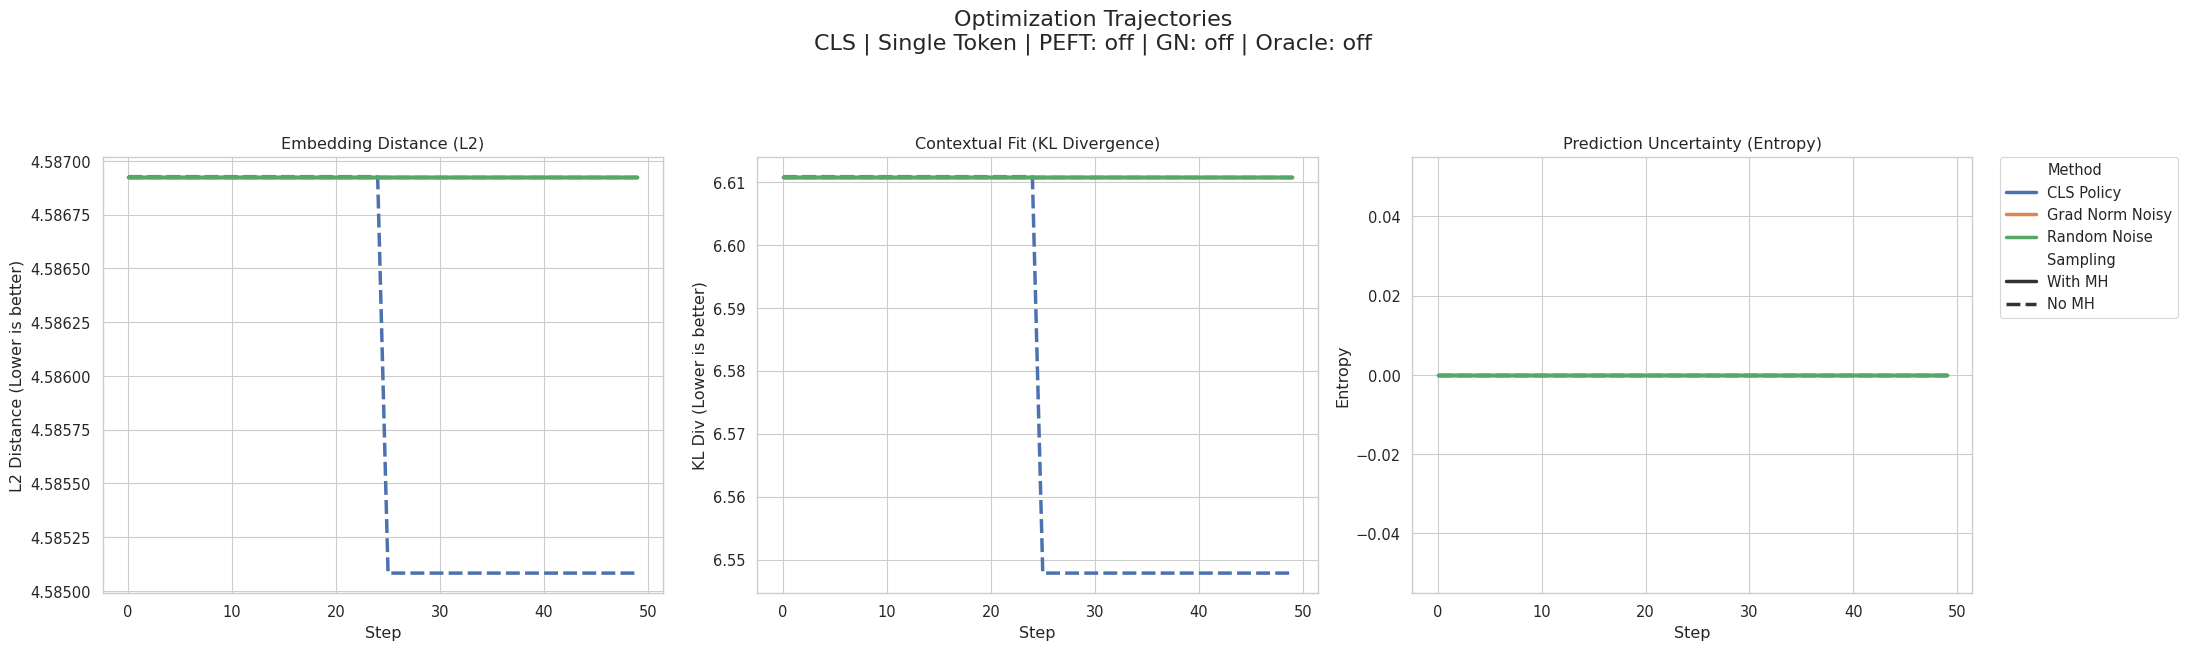

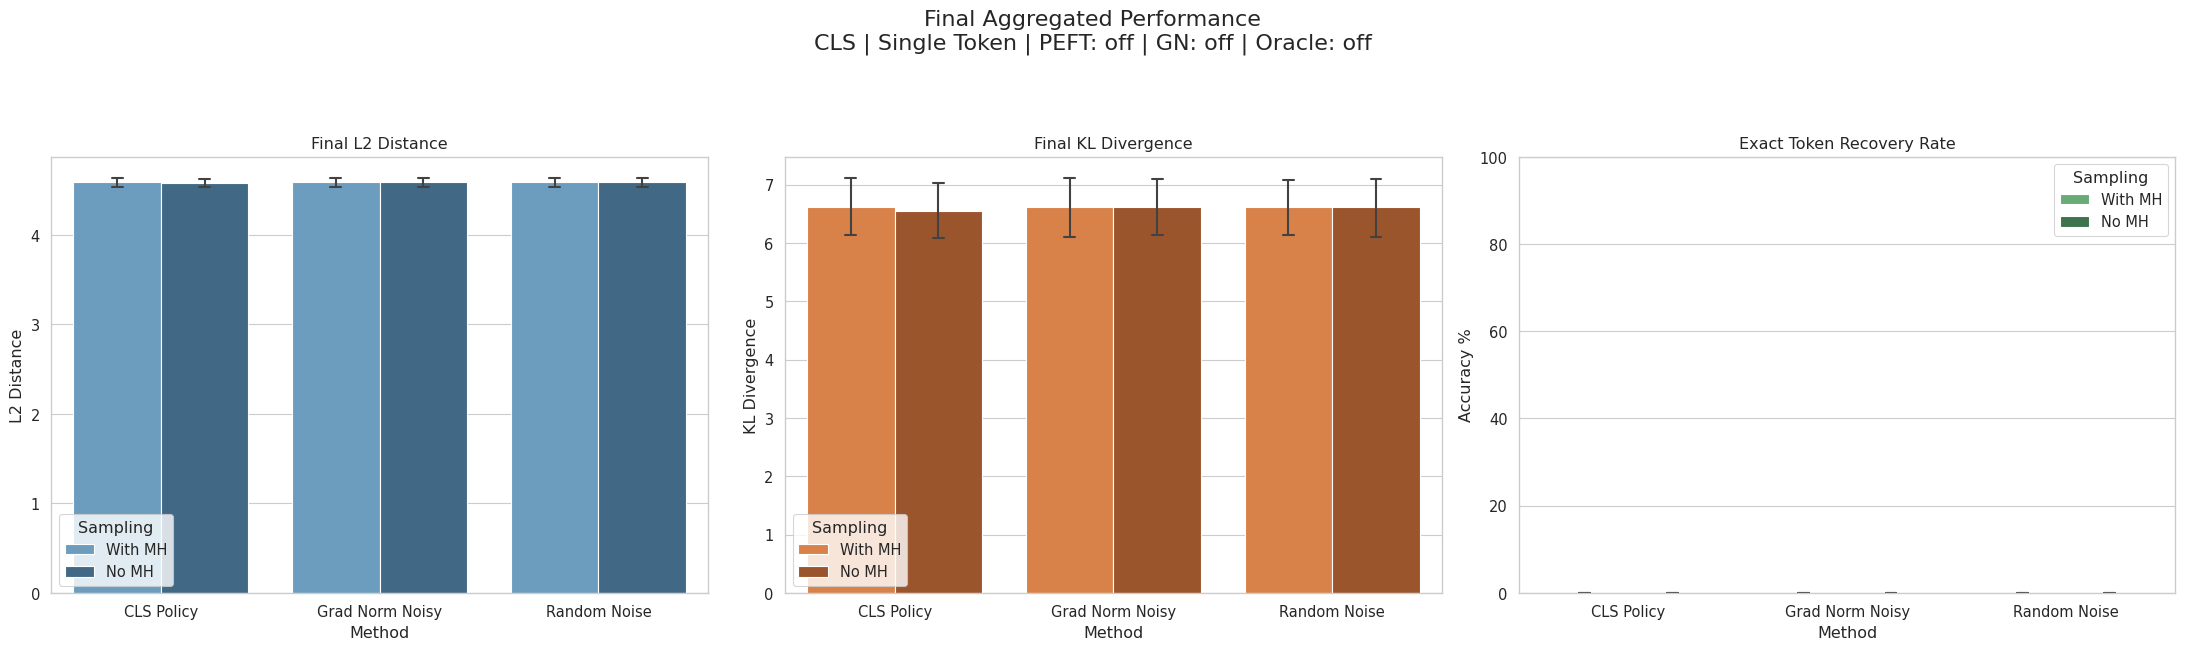


--- Processing: experiment_results_cls_single_steps_50_gn_False_oracle_False_samples_250_date_2026-04-16_peft_True_model_name_gpt2_sft.csv ---
✅ Loaded 1500 experiment records.
Parsing trajectories...
✅ Successfully prepared step & summary records.


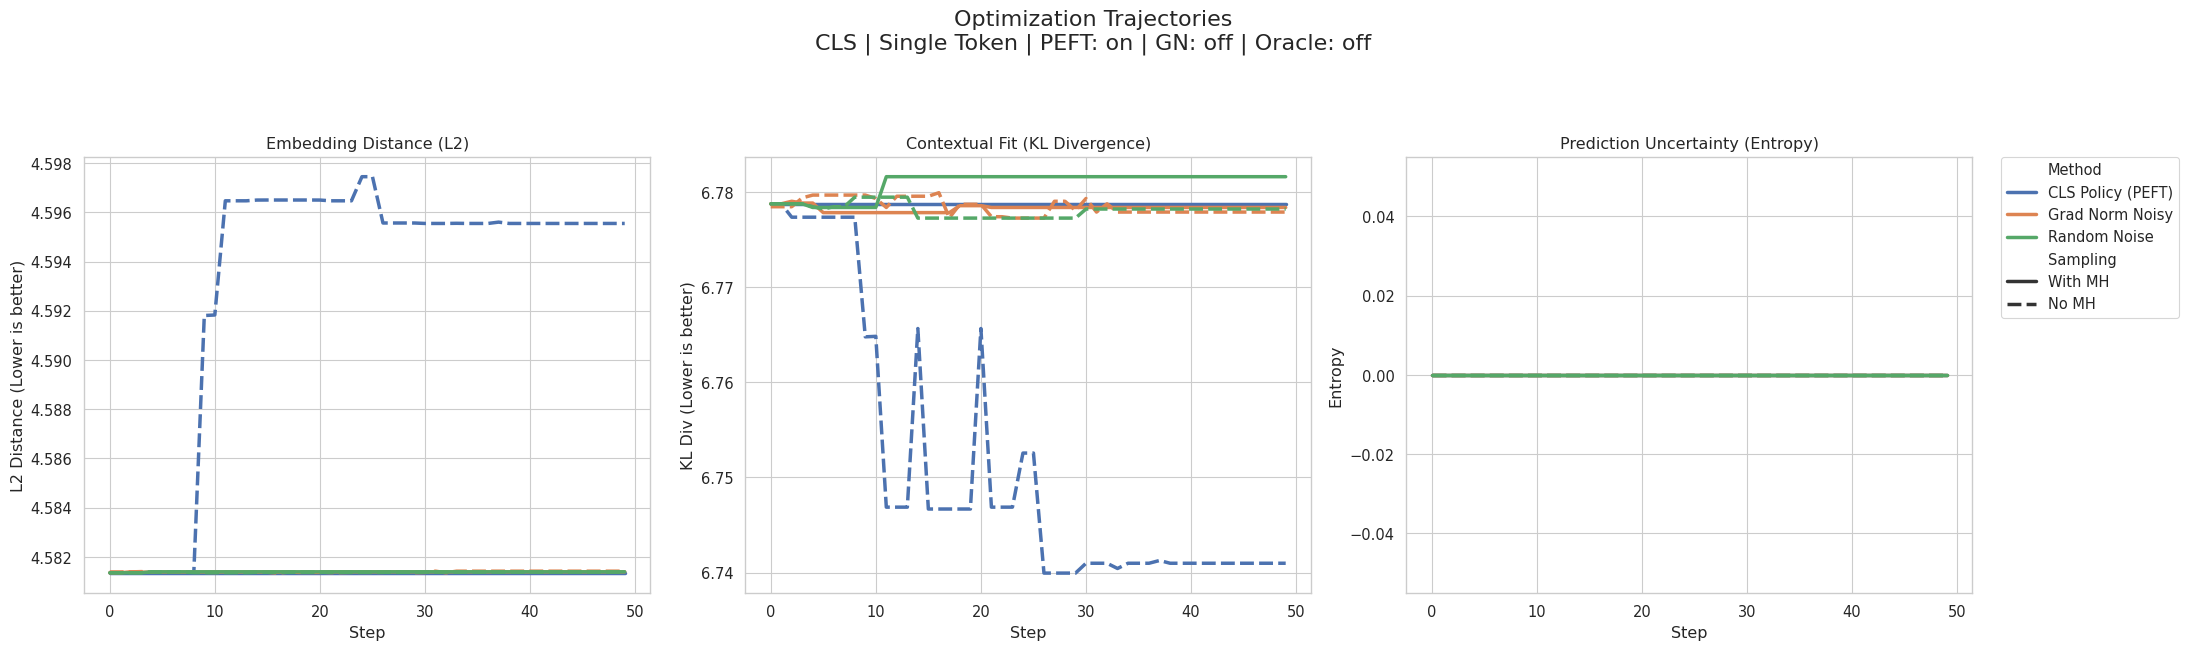

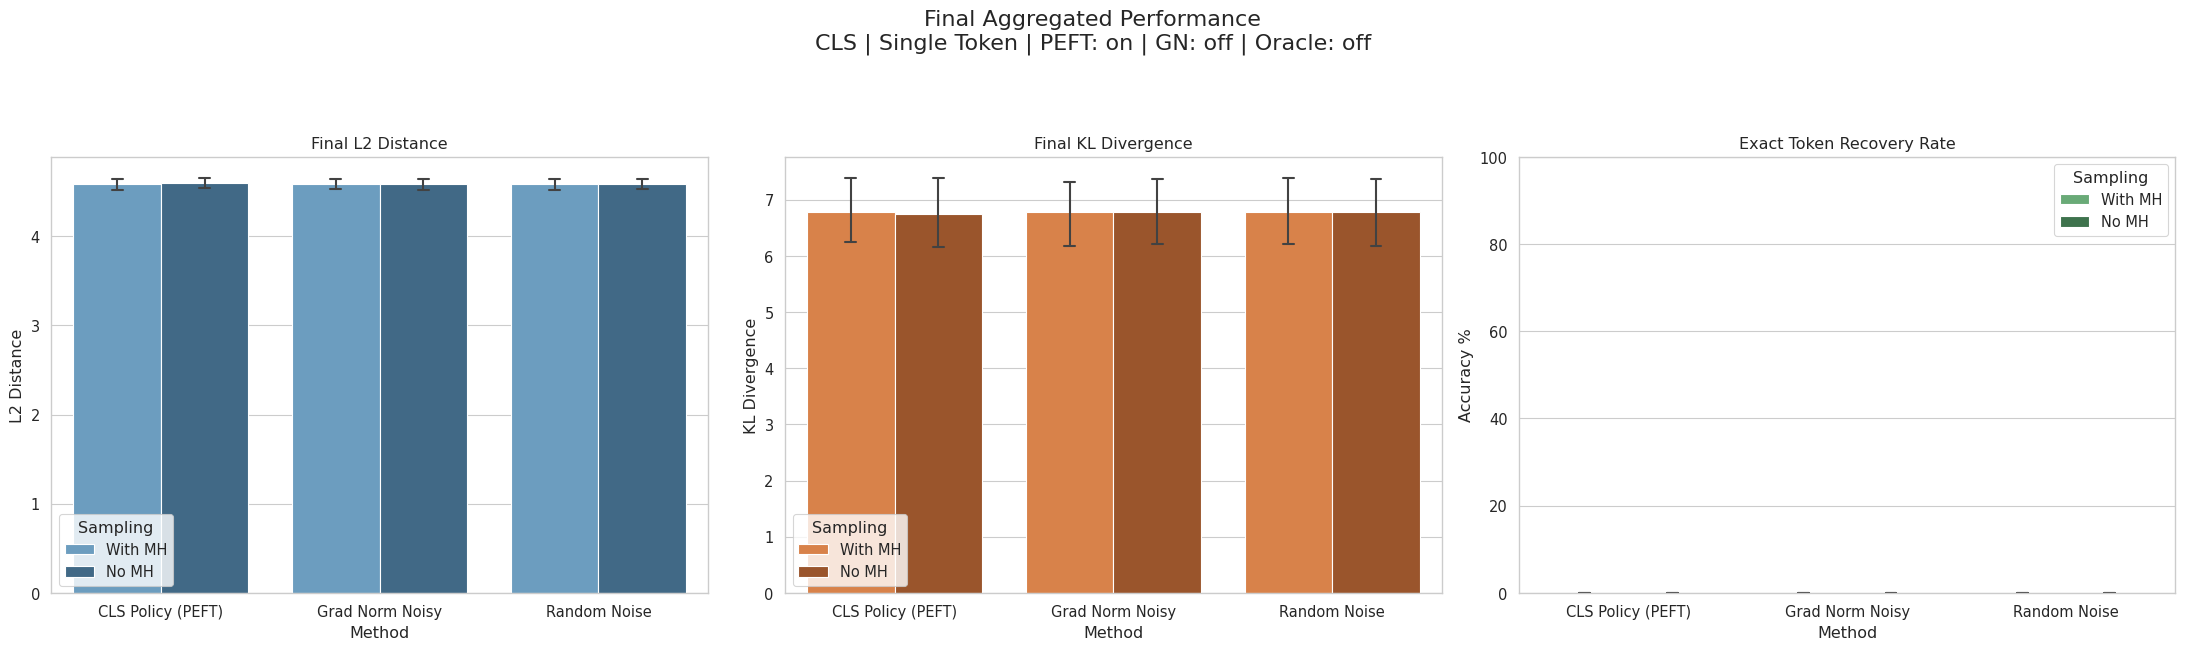


--- Processing: experiment_results_dls_steps_50_gn_True_oracle_False_samples_250_date_2026-04-13.csv ---
✅ Loaded 1500 experiment records.
Parsing trajectories...
✅ Successfully prepared step & summary records.


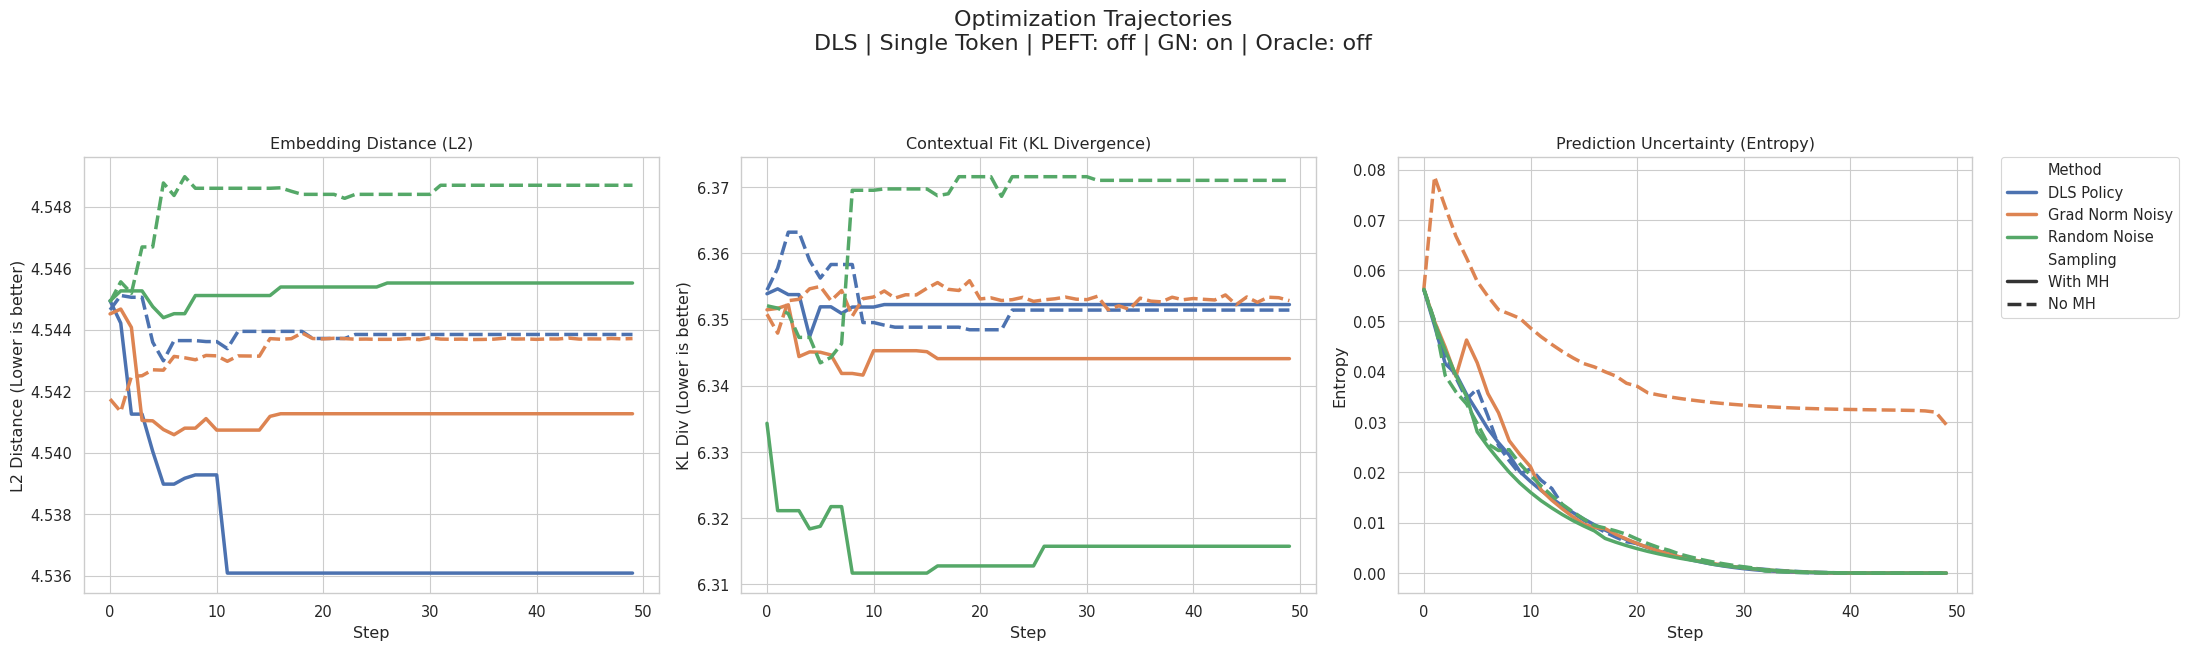

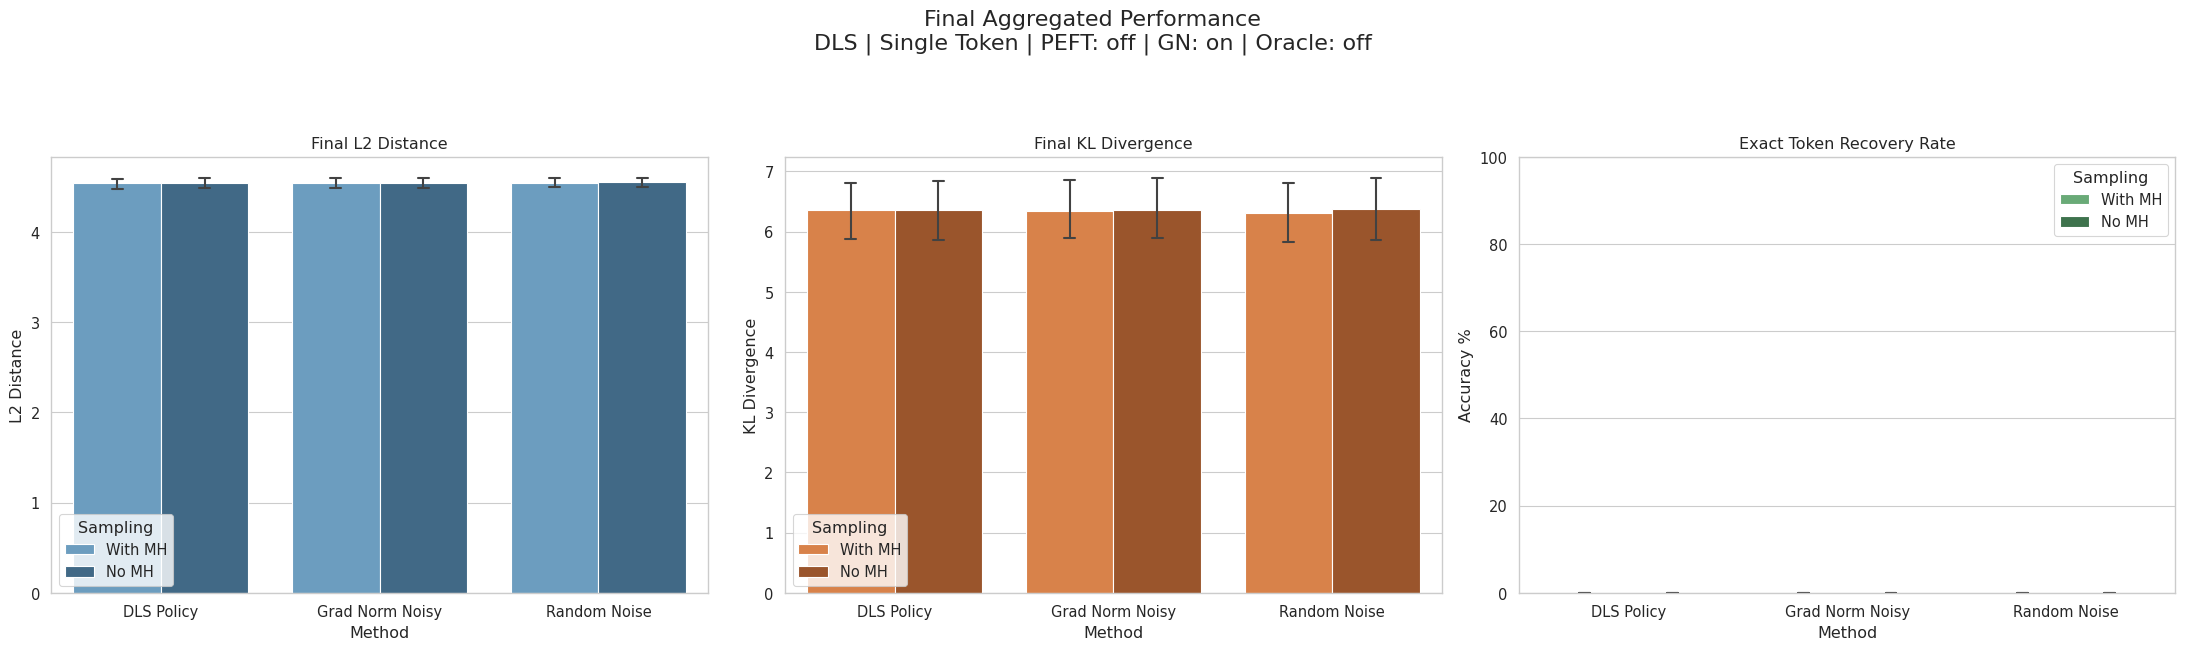


--- Processing: experiment_results_dls_steps_50_gn_True_oracle_False_samples_250_date_2026-04-16_peft_True_model_name_gpt2_sft.csv ---
✅ Loaded 1500 experiment records.
Parsing trajectories...
✅ Successfully prepared step & summary records.


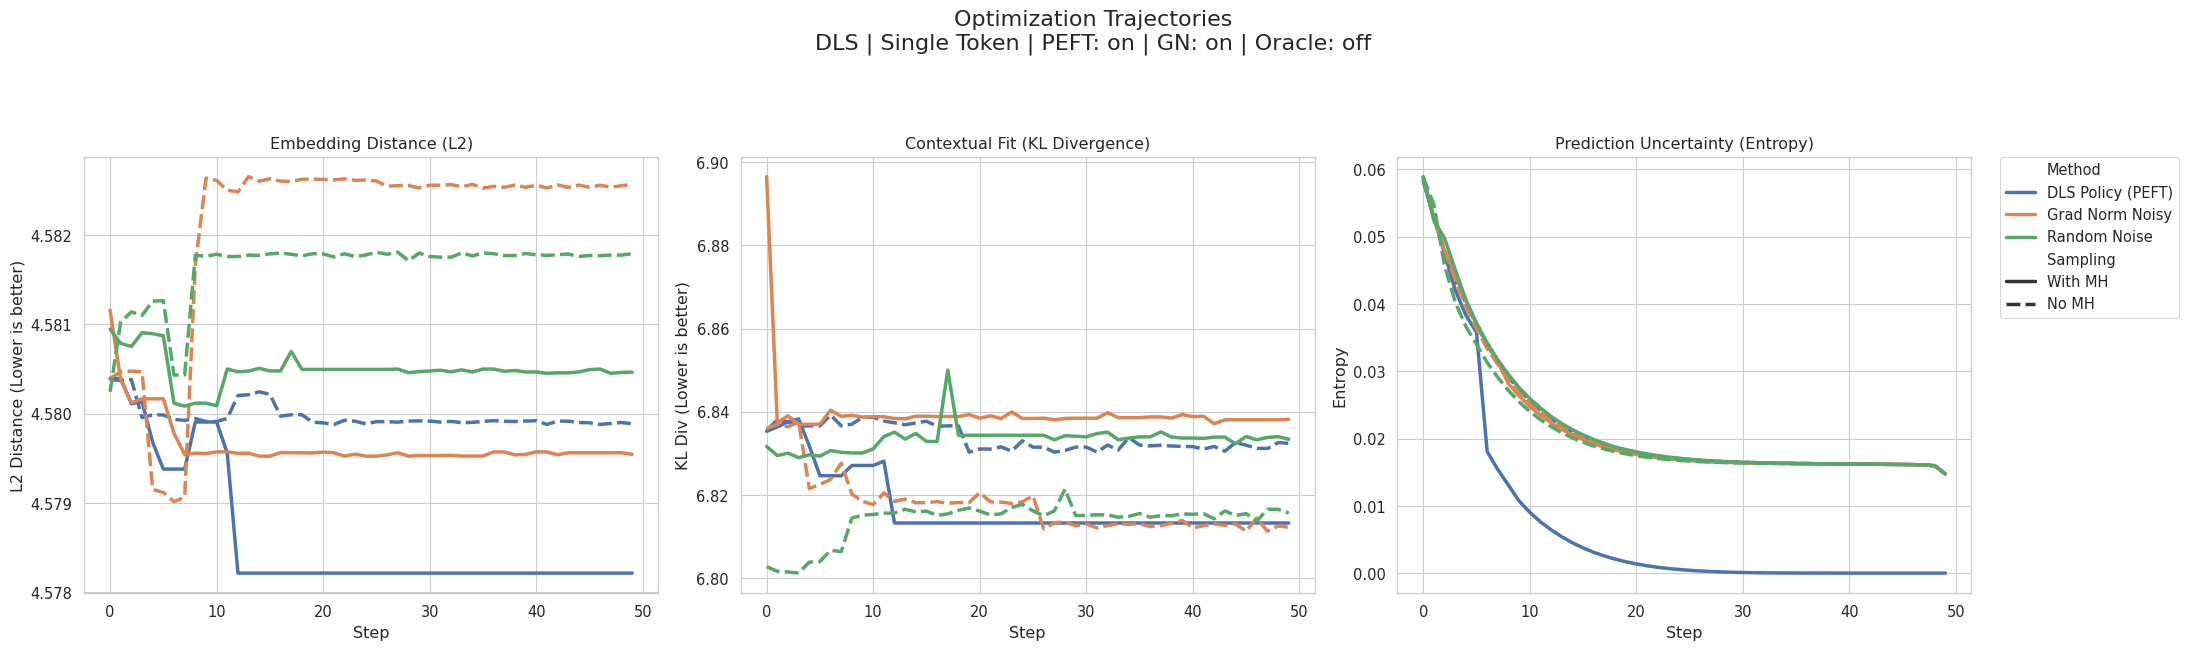

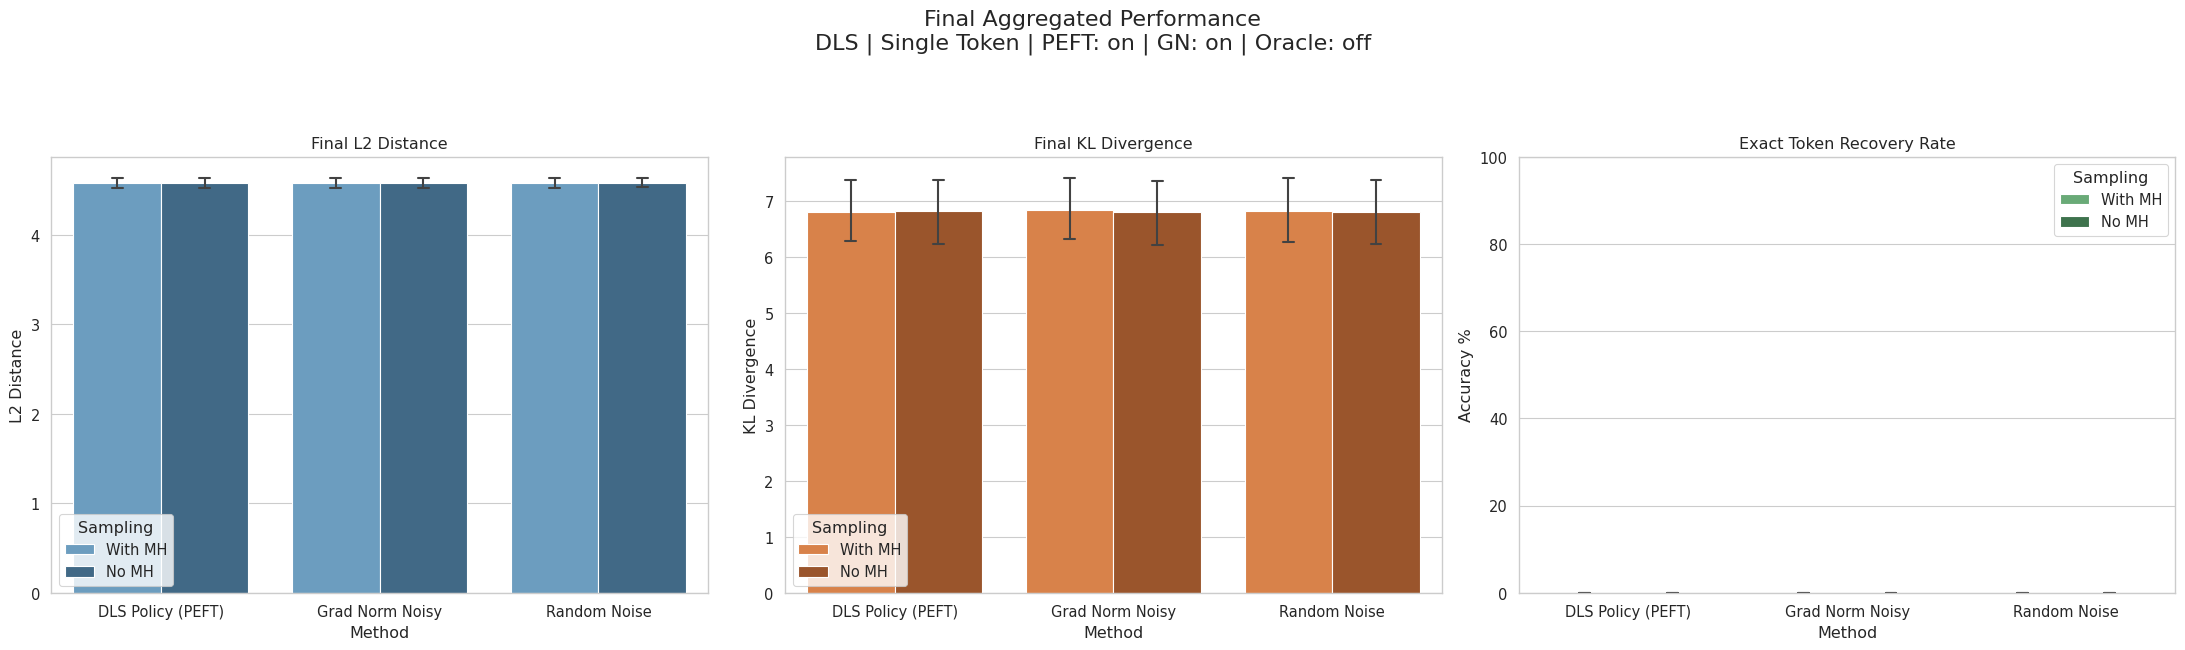

In [4]:


# =============================================================================
# MAIN EXECUTION LOOP
# =============================================================================

filenames =[
    # Put all your single-token and multi-token filenames here
    "experiment_results_cls_multi_steps_50_gn_False_oracle_False_samples_250_date_2026-04-13.csv",
    "experiment_results_dls_multi_sentences_steps_50_gn_True_oracle_False_samples_250_date_2026-04-13.csv",
    "experiment_results_cls_multi_steps_50_gn_False_oracle_False_samples_250_date_2026-04-16_peft_True_model_name_gpt2_sft.csv",
    "experiment_results_dls_multi_sentences_steps_50_gn_True_oracle_False_samples_250_date_2026-04-16_peft_True_model_name_gpt2_sft.csv",
    # Added your single token example:
    "experiment_results_cls_single_steps_50_gn_False_oracle_False_samples_250_date_2026-04-13.csv",
    "experiment_results_cls_single_steps_50_gn_False_oracle_False_samples_250_date_2026-04-16_peft_True_model_name_gpt2_sft.csv",
    "experiment_results_dls_steps_50_gn_True_oracle_False_samples_250_date_2026-04-13.csv",
    "experiment_results_dls_steps_50_gn_True_oracle_False_samples_250_date_2026-04-16_peft_True_model_name_gpt2_sft.csv"
    
]

for filename in filenames:
    # Auto-generate config dictionary from the filename
    config = {
        'method': "CLS" if "cls" in filename else "DLS",
        'tokens_masked': "single" if "single" in filename or "multi" not in filename else "multi",
        'peft': "on" if "peft_True" in filename or "peft" in filename else "off",
        'oracle': "on" if "oracle_True" in filename else "off",
        'gradient_normalization': "on" if "gn_True" in filename else "off"
    }

    try:
        # 1. Prepare data (Handles single or multi structure dynamically)
        traj_df, summary_df = prepare_dataset(filename, config)
        
        # 2. Plot graphs (Applies configs to titles nicely)
        plot_graphs(traj_df, summary_df, config)
    except Exception as e:
        print(f"❌ Failed to process {filename}. Error: {e}")